In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram



In [2]:

orders = pd.read_csv("orders.csv")
order_products_prior = pd.read_csv("order_products__prior.csv")

print("Orders shape:", orders.shape)
print("Prior order products shape:", order_products_prior.shape)

Orders shape: (3421083, 7)
Prior order products shape: (32434489, 4)


In [3]:
data = order_products_prior.merge(
    orders[["order_id", "user_id", "order_number", "order_hour_of_day", "days_since_prior_order"]],
    on="order_id",
    how="left"
)

print("Merged data shape:", data.shape)

Merged data shape: (32434489, 8)


In [4]:
# -------------------------
# CREATE CUSTOMER FEATURES
# -------------------------
customer_features = orders.groupby("user_id").agg(
    total_orders=("order_number", "max"),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    avg_order_hour=("order_hour_of_day", "mean")
).reset_index()

# Order variability
order_variability = orders.groupby("user_id")["order_number"].var().reset_index()
order_variability.columns = ["user_id", "order_variability"]
customer_features = customer_features.merge(order_variability, on="user_id", how="left")

# Basket size
basket_size = data.groupby(["user_id", "order_id"]).size().reset_index(name="basket_size")
avg_basket_size = basket_size.groupby("user_id")["basket_size"].mean().reset_index()
avg_basket_size.columns = ["user_id", "avg_basket_size"]
customer_features = customer_features.merge(avg_basket_size, on="user_id", how="left")

# Reorder rate
reorder_rate = data.groupby("user_id")["reordered"].mean().reset_index()
reorder_rate.columns = ["user_id", "reorder_rate"]
customer_features = customer_features.merge(reorder_rate, on="user_id", how="left")

# Fill missing
customer_features = customer_features.fillna(0)

In [5]:
customer_features["total_orders"] = np.log1p(customer_features["total_orders"])
customer_features["avg_basket_size"] = np.log1p(customer_features["avg_basket_size"])


Scaled feature matrix shape: (5000, 6)


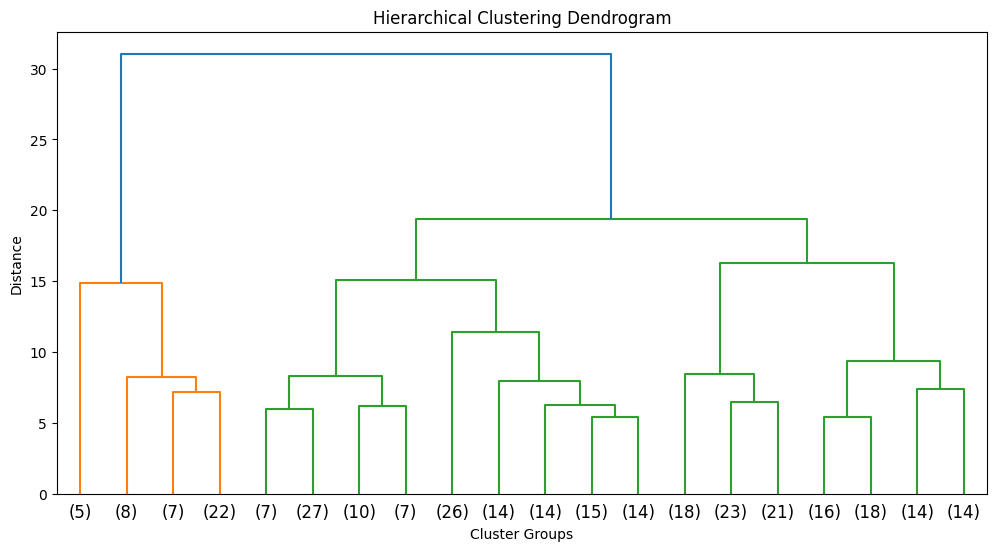

In [7]:
# Create subset from full data
sample_size = 5000   #

customer_subset = customer_features.sample(
    n=min(sample_size, len(customer_features)),
    random_state=42
).copy()
# Select features (remove user_id)
features = customer_subset.drop(columns=["user_id"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("\nScaled feature matrix shape:", scaled_features.shape)

# -------------------------
# 8. DENDROGRAM
#    Use a sample because hierarchical clustering is expensive
# -------------------------
sample_size = 500
np.random.seed(42)
# Sample for clustering
cluster_size = 5000
cluster_idx = np.random.choice(len(scaled_features), size=min(cluster_size, len(scaled_features)), replace=False)
cluster_data = scaled_features[cluster_idx]

# Sample for dendrogram (smaller)
dendro_size = 300
np.random.seed(42)

dendro_idx = np.random.choice(len(scaled_features), size=min(dendro_size, len(scaled_features)), replace=False)
dendro_data = scaled_features[dendro_idx]

linked = linkage(dendro_data, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")
plt.show()

In [8]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 4

hierarchical = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

labels = hierarchical.fit_predict(scaled_features)
customer_subset["hierarchical_cluster"] = labels

print(customer_subset.columns)
print(customer_subset[["user_id", "hierarchical_cluster"]].head())

Index(['user_id', 'total_orders', 'avg_days_between_orders', 'avg_order_hour',
       'order_variability', 'avg_basket_size', 'reorder_rate',
       'hierarchical_cluster'],
      dtype='object')
        user_id  hierarchical_cluster
189032   189033                     3
113006   113007                     3
40368     40369                     1
2152       2153                     3
194849   194850                     2


In [9]:
sample_n = min(10000, len(customer_subset))

score = silhouette_score(
    scaled_features,
    customer_subset["hierarchical_cluster"],
    sample_size=sample_n,
    random_state=42
)

print(f"\nSilhouette Score: {score:.4f}")



Silhouette Score: 0.1712


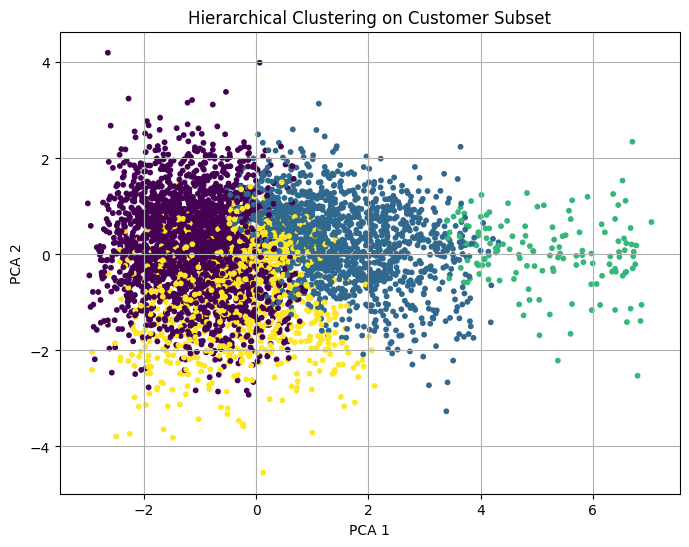

In [10]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=customer_subset["hierarchical_cluster"],
    s=10
)
plt.title("Hierarchical Clustering on Customer Subset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [11]:
cluster_profile = customer_subset.drop(columns=["user_id"]).groupby("hierarchical_cluster").mean()

print("\nCluster Profile:")
print(cluster_profile)


Cluster Profile:
                      total_orders  avg_days_between_orders  avg_order_hour  \
hierarchical_cluster                                                          
0                         2.062016                18.982681       13.554887   
1                         3.272269                10.548786       13.544787   
2                         4.398489                 4.345113       13.483990   
3                         2.409763                15.997036       13.743694   

                      order_variability  avg_basket_size  reorder_rate  
hierarchical_cluster                                                    
0                              6.526427         2.360730      0.289446  
1                             84.511791         2.485106      0.620694  
2                            575.706573         2.294603      0.744960  
3                             15.208863         1.635077      0.435121  


In [12]:
cluster_counts = customer_subset["hierarchical_cluster"].value_counts().sort_index()

print("\nCluster Counts:")
print(cluster_counts)


Cluster Counts:
hierarchical_cluster
0    2365
1    1470
2     142
3    1023
Name: count, dtype: int64


In [13]:
customer_subset.to_csv("customer_segmentation_hierarchical_results.csv", index=False)
cluster_profile.to_csv("customer_segmentation_hierarchical_cluster_profile.csv")

print("\nFiles saved:")
print("- customer_segmentation_hierarchical_results.csv")
print("- customer_segmentation_hierarchical_cluster_profile.csv")


Files saved:
- customer_segmentation_hierarchical_results.csv
- customer_segmentation_hierarchical_cluster_profile.csv
